In [23]:
from mplbasketball.court3d import draw_court_3d
import matplotlib.pyplot as plt
import numpy as np
from nba_api.stats.endpoints import leaguegamefinder
from nba_api.stats.endpoints import playbyplayv3
import pandas as pd

In [24]:
gamefinder = leaguegamefinder.LeagueGameFinder(
    season_nullable="2022-23",
    season_type_nullable="Playoffs"
)

games = gamefinder.get_data_frames()[0]

# Filter for April 24, 2023 and MIA vs MIL
games_filtered = games[
    (games["GAME_DATE"] == "2023-04-24") &
    (games["MATCHUP"].str.contains("MIA"))
]

game_id = games_filtered[["GAME_ID", "MATCHUP", "GAME_DATE"]].iloc[0]["GAME_ID"]
game_id

'0042200104'

In [25]:
pbp = playbyplayv3.PlayByPlayV3(game_id=game_id)
pbp_df = pbp.get_data_frames()[0]

pbp_df.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId
0,0042200104,2,PT12M00.00S,1,0,,0,,,0,...,0,0,0,,Start of 1st Period (7:36 PM EST),period,start,0,0,1
1,0042200104,4,PT12M00.00S,1,1610612748,MIA,1628389,Adebayo,B. Adebayo,0,...,,,0,h,Jump Ball Adebayo vs. Lopez: Tip to G. Antetok...,Jump Ball,,1,0,2
2,0042200104,7,PT11M37.00S,1,1610612749,MIL,1628960,Allen,G. Allen,234,...,,,0,v,MISS Allen 25' 3PT Pullup Jump Shot,Missed Shot,Pullup Jump shot,1,3,3
3,0042200104,8,PT11M34.00S,1,1610612748,MIA,1628389,Adebayo,B. Adebayo,0,...,,,0,h,Adebayo REBOUND (Off:0 Def:1),Rebound,Unknown,1,0,4
4,0042200104,9,PT11M26.00S,1,1610612748,MIA,1628389,Adebayo,B. Adebayo,0,...,,,0,h,Adebayo Lost Ball Turnover (P1.T1),Turnover,Lost Ball,1,0,5


In [26]:
pbp_df[pbp_df['actionType'] == 'Made Shot']

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId
10,0042200104,15,PT10M59.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,-16,...,0,2,2,v,G. Antetokounmpo 2' Running Layup (2 PTS),Made Shot,Running Layup Shot,1,2,11
13,0042200104,18,PT10M34.00S,1,1610612749,MIL,201572,Lopez,B. Lopez,232,...,0,5,5,v,Lopez 3PT Jump Shot (3 PTS) (Holiday 1 AST),Made Shot,Jump Shot,1,3,14
16,0042200104,22,PT09M59.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,-25,...,0,7,7,v,G. Antetokounmpo 3' Driving Dunk (4 PTS),Made Shot,Driving Dunk Shot,1,2,17
21,0042200104,27,PT09M19.00S,1,1610612748,MIA,201567,Love,K. Love,239,...,3,7,10,h,Love 25' 3PT Jump Shot (3 PTS) (Butler 1 AST),Made Shot,Jump Shot,1,3,22
22,0042200104,29,PT09M03.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,18,...,3,9,12,v,G. Antetokounmpo 2' Driving Layup (6 PTS) (Mid...,Made Shot,Driving Layup Shot,1,2,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,0042200104,640,PT02M26.00S,4,1610612749,MIL,201950,Holiday,J. Holiday,9,...,105,107,212,v,Holiday 27' 3PT Step Back Jump Shot (14 PTS) (...,Made Shot,Step Back Jump shot,1,3,464
470,0042200104,650,PT01M32.00S,4,1610612749,MIL,201572,Lopez,B. Lopez,0,...,107,109,216,v,Lopez 1' Cutting Dunk Shot (33 PTS) (G. Anteto...,Made Shot,Cutting Dunk Shot,1,2,471
471,0042200104,652,PT01M20.00S,4,1610612748,MIA,202710,Butler III,J. Butler III,77,...,110,109,219,h,Butler 27' 3PT Pullup Jump Shot (49 PTS),Made Shot,Pullup Jump shot,1,3,472
474,0042200104,655,PT00M58.20S,4,1610612748,MIA,202710,Butler III,J. Butler III,-207,...,112,109,221,h,Butler 22' Step Back Jump Shot (51 PTS),Made Shot,Step Back Jump shot,1,2,475


In [27]:
pbp_df["actionType"].value_counts()

actionType
Rebound           107
Missed Shot        99
Made Shot          85
Substitution       50
Free Throw         45
Foul               40
Turnover           30
                   30
Timeout            13
period              8
Instant Replay      5
Jump Ball           1
Name: count, dtype: int64

## Visuals

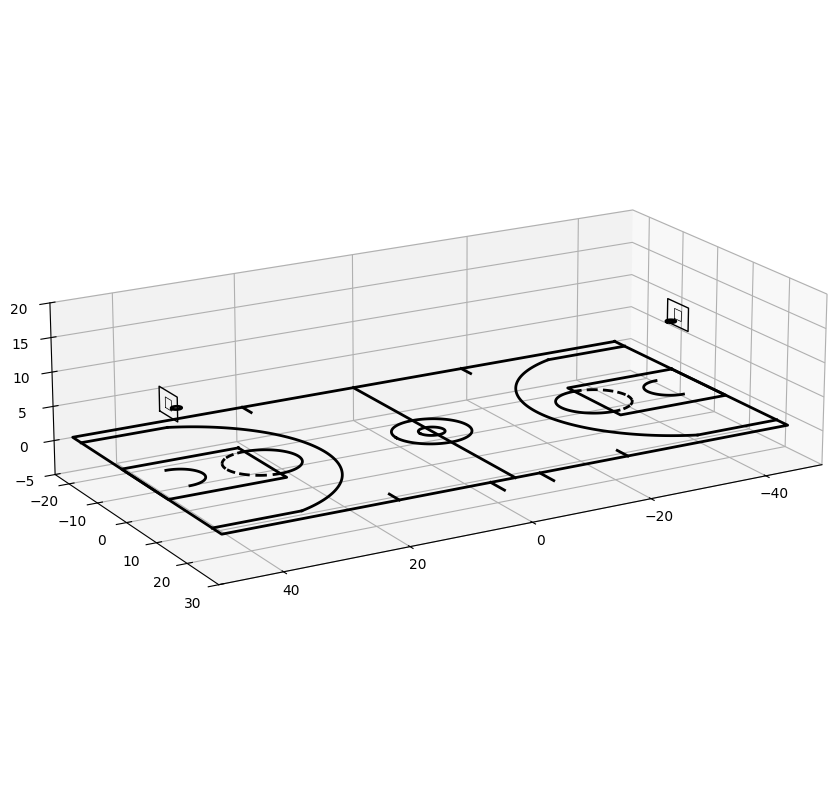

In [32]:
zmin, zmax = -5, 20

fig = plt.figure(figsize=(50, 10))
ax = fig.add_subplot(111, projection="3d")

ax.set_zlim(zmin, zmax)
ax.set_box_aspect((1.9, 1.0, 0.5))  # adjust if axes swapped
ax.view_init(elev=18, azim=60)

ax.set_xlim(-50, 50)
ax.set_ylim(-25, 30)

draw_court_3d(ax, origin=np.array([0.0, 0.0]), line_width=2)

plt.show()